In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
 

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\duan\da\Bank's Customer Churn\data\raw\Churn_Modelling.csv")

print("Kích thước dữ liệu:", df.shape)
print(df.head())
print(df.columns.tolist())
print(df["Exited"].value_counts())

Kích thước dữ liệu: (10000, 14)
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         

In [12]:
# Target: chỉ lấy một cột Exited
y = df["Exited"]

# Features: bỏ target và các cột định danh
X = df.drop(
    columns=["Exited", "RowNumber", "CustomerId", "Surname"],
    errors="ignore"
)

print("X:", X.shape)
print("y:", y.shape)
print("Các giá trị target:")
print(y.value_counts())

X: (10000, 10)
y: (10000,)
Các giá trị target:
Exited
0    7963
1    2037
Name: count, dtype: int64


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (8000, 10)
y_train: (8000,)
X_test: (2000, 10)
y_test: (2000,)


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

categorical_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_cols = X.select_dtypes(
    include=np.number
).columns.tolist()

print("Categorical:", categorical_cols)
print("Numerical:", numeric_cols)

# Tiền xử lý cho Logistic Regression
preprocessor_lr = ColumnTransformer([
    (
        "num",
        StandardScaler(),
        numeric_cols
    ),
    (
        "cat",
        OneHotEncoder(handle_unknown="ignore"),
        categorical_cols
    )
])

# Tiền xử lý cho Random Forest
preprocessor_rf = ColumnTransformer([
    (
        "num",
        "passthrough",
        numeric_cols
    ),
    (
        "cat",
        OneHotEncoder(handle_unknown="ignore"),
        categorical_cols
    )
])

Categorical: ['Geography', 'Gender']
Numerical: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


C:\Users\tommy\AppData\Local\Temp\ipykernel_17396\3730417721.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(


In [15]:
model_lr = Pipeline([
    ("preprocessor", preprocessor_lr),
    ("model", LogisticRegression(max_iter=1000))
])

model_rf = Pipeline([
    ("preprocessor", preprocessor_rf),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

# Train
model_lr.fit(X_train, y_train)
model_rf.fit(X_train, y_train)

print("Đã train xong hai model!")

Đã train xong hai model!


In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {
    "Logistic Regression": model_lr,
    "Random Forest": model_rf
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "F1-score": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
print(results_df.round(4))

                 Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
0  Logistic Regression    0.8080     0.5891  0.1867    0.2836   0.7748
1        Random Forest    0.8405     0.6140  0.5823    0.5977   0.8505


              precision    recall  f1-score   support

    Retained       0.89      0.91      0.90      1593
     Churned       0.61      0.58      0.60       407

    accuracy                           0.84      2000
   macro avg       0.75      0.74      0.75      2000
weighted avg       0.84      0.84      0.84      2000



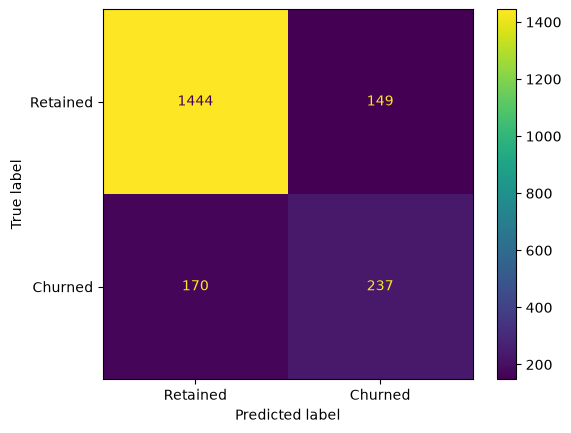

In [17]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model = model_rf

y_pred = best_model.predict(X_test)

print(classification_report(
    y_test,
    y_pred,
    target_names=["Retained", "Churned"]
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Retained", "Churned"]
)

plt.show()

In [18]:
# Xác suất khách hàng thuộc class Exited = 1
churn_probability = best_model.predict_proba(X_test)[:, 1]

predictions = pd.DataFrame({
    "CustomerId": df.loc[X_test.index, "CustomerId"],
    "Actual_Exited": y_test,
    "Churn_Probability": churn_probability
})

predictions["Predicted_Exited"] = (
    predictions["Churn_Probability"] >= 0.5
).astype(int)

predictions["Risk_Level"] = pd.cut(
    predictions["Churn_Probability"],
    bins=[-0.001, 0.4, 0.7, 1.0],
    labels=["Low", "Medium", "High"]
)

predictions.to_csv(
    "customer_churn_predictions_test.csv",
    index=False
)

print(predictions.head())

      CustomerId  Actual_Exited  Churn_Probability  Predicted_Exited  \
5702    15749540              0           0.113333                 0   
3667    15807340              0           0.126667                 0   
1617    15801062              0           0.190000                 0   
5673    15572801              0           0.056667                 0   
4272    15600708              0           0.176667                 0   

     Risk_Level  
5702        Low  
3667        Low  
1617        Low  
5673        Low  
4272        Low  
